In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import importlib

import env.trading_env as te
import features.feature_engineering as fe
importlib.reload(te)
importlib.reload(fe)


<module 'features.feature_engineering' from 'C:\\DKU\\26spring\\stats402\\project\\notebooks\\..\\features\\feature_engineering.py'>

In [2]:
# Read data
df = pd.read_excel('../data/data.xlsx', skiprows=6, header=0)
df.columns = ['date', 'gold', 'silver', 'copper']
df = df[pd.to_datetime(df['date'], errors='coerce').notna()]
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [3]:
# Feature engineering
features_final = fe.build_features(df)

# Split
train = features_final[features_final.index <= '2023-12-31']
test = features_final[features_final.index >= '2024-01-01']
price_train = df[df.index.isin(train.index)]
price_test = df[df.index.isin(test.index)]

print(f"Train: {len(train)}days, Test: {len(test)}days")

Train: 2592days, Test: 485days


finish training


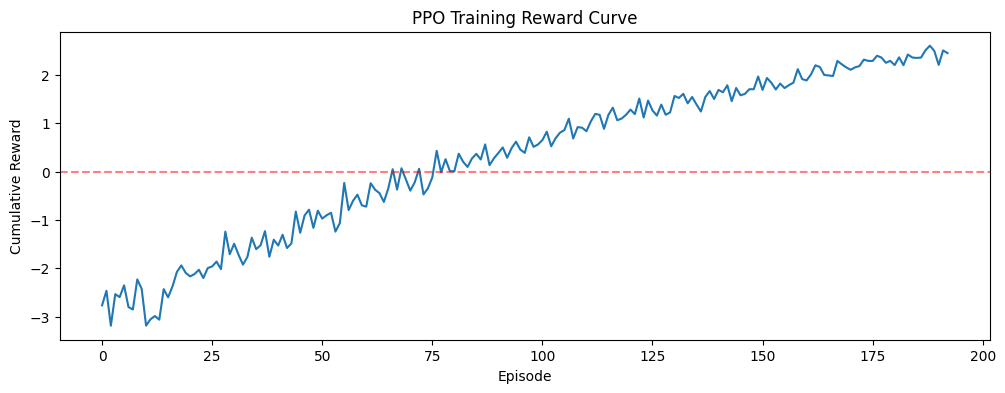

Average reward for the last 10 episodes: 2.4249


In [6]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
import matplotlib.pyplot as plt

class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_rewards = []
    
    def _on_step(self):
        reward = self.locals['rewards'][0]
        self.current_rewards.append(reward)
        
        if self.locals['dones'][0]:
            self.episode_rewards.append(sum(self.current_rewards))
            self.current_rewards = []
        return True

# initialization
train_env = te.MetalTradingEnv(train, price_train)
callback = RewardCallback()

model_500k = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    verbose=0 
)

model_500k.learn(total_timesteps=500_000, callback=callback)
print("finish training")

# reward plot
plt.figure(figsize=(12, 4))
plt.plot(callback.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("PPO Training Reward Curve")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback.episode_rewards[-10:])/10:.4f}")

In [7]:
# Save a 500k model
model_500k.save("../agents/ppo_metal_500k")

# Save the reward curve data
import numpy as np
np.save("../agents/ppo_rewards_500k.npy", callback.episode_rewards)
print("The 500k model and reward curve have been saved")

The 500k model and reward curve have been saved


finish training


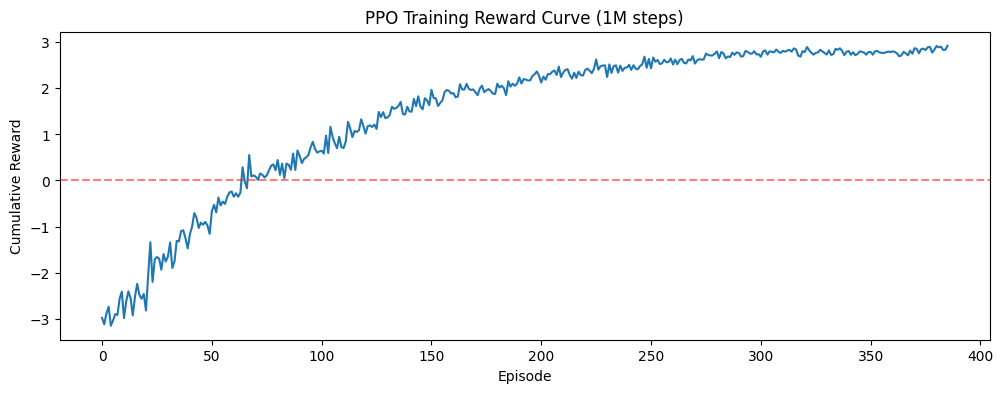

Average reward for the last 10 episodes: 2.8729


In [8]:
train_env = te.MetalTradingEnv(train, price_train)
callback_1m = RewardCallback()

model_1m = PPO(
    "MlpPolicy",
    train_env,
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    verbose=0
)

model_1m.learn(total_timesteps=1_000_000, callback=callback_1m)
print("finish training")


# 画图
plt.figure(figsize=(12, 4))
plt.plot(callback_1m.episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.title("PPO Training Reward Curve (1M steps)")
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.show()

print(f"Average reward for the last 10 episodes: {sum(callback_1m.episode_rewards[-10:])/10:.4f}")

In [9]:
# Save
model_1m.save("../agents/ppo_metal_1m")
np.save("../agents/ppo_rewards_1m.npy", callback_1m.episode_rewards)